In [1]:
from __future__ import division, print_function
import sys, os, glob, time, warnings, gc
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table, vstack, hstack, join
import fitsio

from astropy.io import fits
from astropy import wcs

from scipy.interpolate import RectBivariateSpline

from astropy import units as u
from astropy.coordinates import SkyCoord

In [2]:
params = {'legend.fontsize': 'large',
         'axes.labelsize': 'large',
         'axes.titlesize':'large',
         'xtick.labelsize':'large',
         'ytick.labelsize':'large',
         'figure.facecolor':'w'} 
plt.rcParams.update(params)

In [3]:
field = 'north'

In [4]:
bricks = Table(fitsio.read('/global/cfs/cdirs/cosmo/data/legacysurvey/dr9/north/survey-bricks-dr9-north.fits.gz'))
print(len(bricks))

mask = bricks['brickname']=='1003p350'
brick_index = np.where(mask)[0][0]
brickname = str(bricks['brickname'][brick_index])
bricks[mask]

93548


brickname,ra,dec,nexp_g,nexp_r,nexp_z,nexphist_g [6],nexphist_r [6],nexphist_z [6],nobjs,npsf,nsimp,nrex,nexp,ndev,ncomp,nser,ndup,psfsize_g,psfsize_r,psfsize_z,psfdepth_g,psfdepth_r,psfdepth_z,galdepth_g,galdepth_r,galdepth_z,ebv,trans_g,trans_r,trans_z,cosky_g,cosky_r,cosky_z,ext_g,ext_r,ext_z,wise_nobs [4],trans_wise [4],ext_w1,ext_w2,ext_w3,ext_w4,brickid,ra1,ra2,dec1,dec2,area,survey_primary,in_desi
str8,float64,float64,int16,int16,int16,int32,int32,int32,int32,int32,int32,int32,int32,int32,int32,int32,int32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,int16,float32,float32,float32,float32,float32,int32,float64,float64,float64,float64,float64,bool,bool
1003p350,100.35532994923858,35.0,5,3,3,140595 .. 8230618,190658 .. 419732,52738 .. 976990,5650,3919,0,1396,202,95,0,37,1,1.872777,1.6427066,1.4995861,24.724747,23.875797,23.349333,24.537506,23.664856,23.093723,0.14209822,0.6566267,0.7532566,0.85342944,0.00012917015,0.00012152935,7.667978e-05,0.45670363,0.3076426,0.17208096,197 .. 11,0.97620624 .. 0.99880975,0.026146047,0.016057115,0.0034245432,0.001293062,520381,100.20304568527922,100.50761421319794,34.875,35.125,0.06237198306767673,True,False


In [5]:
gaia_path = '/global/cfs/cdirs/desi/users/rongpu/desi_mask/gaia_lrg_mask_v1.fits'
gaia_columns = ['RA', 'DEC', 'mask_mag', 'radius_south', 'radius_north']

hdu = fits.open(gaia_path)
gaia = Table()
for col in gaia_columns:
    gaia[col] = np.copy(hdu[1].data[col])

In [6]:
ra2, dec2 = np.array(gaia['RA']), np.array(gaia['DEC'])
sky2 = SkyCoord(ra2*u.degree, dec2*u.degree, frame='icrs')

In [7]:
ra1, dec1 = [bricks['ra'][brick_index]], [bricks['dec'][brick_index]]
sky1 = SkyCoord(ra1*u.degree, dec1*u.degree, frame='icrs')

search_radius = gaia['radius_'+field].max() + 0.2*3600
_, idx2, d2d, _ = sky2.search_around_sky(sky1, seplimit=search_radius*u.arcsec)
print(len(idx2))

d2d = np.array(d2d.to(u.arcsec))
mask = d2d < (gaia['radius_'+field][idx2] + 0.2*3600)
print(np.sum(mask))
idx2 = idx2[mask]
d2d = d2d[mask]

11266
813


398


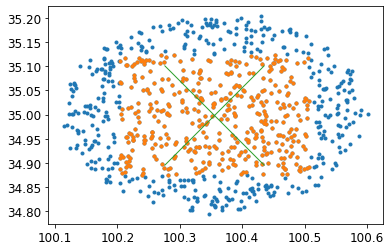

In [8]:
ramin, ramax, decmin, decmax = bricks['ra1'][brick_index], bricks['ra2'][brick_index], bricks['dec1'][brick_index], bricks['dec2'][brick_index]
mask = (gaia['RA'][idx2]>ramin) & (gaia['RA'][idx2]<ramax) & (gaia['DEC'][idx2]>decmin) & (gaia['DEC'][idx2]<decmax)
print(np.sum(mask))

plt.plot(gaia['RA'][idx2], gaia['DEC'][idx2], '.')
plt.plot(gaia['RA'][idx2[mask]], gaia['DEC'][idx2[mask]], '.')
plt.plot(ra1, dec1, 'x', ms=100)
plt.show()

In [9]:
sky2_brick = SkyCoord(ra2[idx2]*u.degree, dec2[idx2]*u.degree, frame='icrs')
gaia_brick = gaia[idx2].copy()

In [10]:
%%time

img_fn = '/global/cfs/cdirs/cosmo/data/legacysurvey/dr9/north/coadd/{}/{}/legacysurvey-{}-maskbits.fits.fz'.format(brickname[:3], brickname, brickname)
hdulist = fits.open(img_fn, hdu=1)

w = wcs.WCS(hdulist[1].header)
naxis1 = hdulist[1].header['NAXIS1']  # Length of the *second* index of the 2-D array
naxis2 = hdulist[1].header['NAXIS2']  # Length of the *first* index of the 2-D array

if naxis1!=3600 or naxis2!=3600:
    raise ValueError

binsize = 1000
pix_x_spline, pix_y_spline = np.arange(-binsize, naxis1+2*binsize, binsize), np.arange(-binsize, naxis2+2*binsize, binsize)
xx, yy = np.meshgrid(pix_x_spline, pix_y_spline)
pix_ra_spline, pix_dec_spline = w.wcs_pix2world(xx, yy, 0)

interp_ra = RectBivariateSpline(pix_y_spline, pix_x_spline, pix_ra_spline)
interp_dec = RectBivariateSpline(pix_y_spline, pix_x_spline, pix_dec_spline)

chunk_size = 400
if naxis1%chunk_size!=0:
    raise ValueError
n_chunks = naxis1//chunk_size

newmask_i = []
for i in range(n_chunks):

    newmask_j = []
    for j in range(n_chunks):

        pix_ra = interp_ra(i*chunk_size+np.arange(chunk_size), j*chunk_size+np.arange(chunk_size)).flatten()
        pix_dec = interp_dec(i*chunk_size+np.arange(chunk_size), j*chunk_size+np.arange(chunk_size)).flatten()

        sky1_brick = SkyCoord([np.mean(pix_ra)]*u.degree, [np.mean(pix_dec)]*u.degree, frame='icrs')

        _, idx2, d2d, _ = sky2_brick.search_around_sky(sky1_brick, seplimit=search_radius*u.arcsec)

        d2d = np.array(d2d.to(u.arcsec))
        mask = d2d < (gaia_brick['radius_'+field][idx2] + 0.2*chunk_size/3600*3600)
        idx2 = idx2[mask]
        # print(len(idx2))

        if len(idx2)==0:
            newmask = np.full((chunk_size, chunk_size), False)
            newmask_j.append(newmask)
            continue

        # RA/DEC to unit cartesian vectors
        pix_cx = np.cos(np.radians(pix_ra))*np.cos(np.radians(pix_dec))
        pix_cy = np.sin(np.radians(pix_ra))*np.cos(np.radians(pix_dec))
        pix_cz = np.sin(np.radians(pix_dec))

        star_ra = gaia_brick['RA'][idx2]
        star_dec = gaia_brick['DEC'][idx2]
        mask_radii = gaia_brick['radius_'+field][idx2]

        # RA/DEC to unit cartesian vectors
        star_cx = np.cos(np.radians(star_ra))*np.cos(np.radians(star_dec))
        star_cy = np.sin(np.radians(star_ra))*np.cos(np.radians(star_dec))
        star_cz = np.sin(np.radians(star_dec))

        mat1 = np.array([pix_cx, pix_cy, pix_cz]).T
        mat2 = np.array([star_cx, star_cy, star_cz])
        del pix_cx, pix_cy, pix_cz, star_cx, star_cy, star_cz

        dist = np.dot(mat1, mat2)
        newmask = np.any(dist>np.cos(np.radians(mask_radii/3600.)), axis=1).reshape(chunk_size, chunk_size)

        newmask = newmask.reshape(chunk_size, chunk_size)
        newmask_j.append(newmask)
        
    newmask_i.append(np.hstack(newmask_j))

newmask = np.vstack(newmask_i)

CPU times: user 3.17 s, sys: 37.6 ms, total: 3.21 s
Wall time: 3.24 s


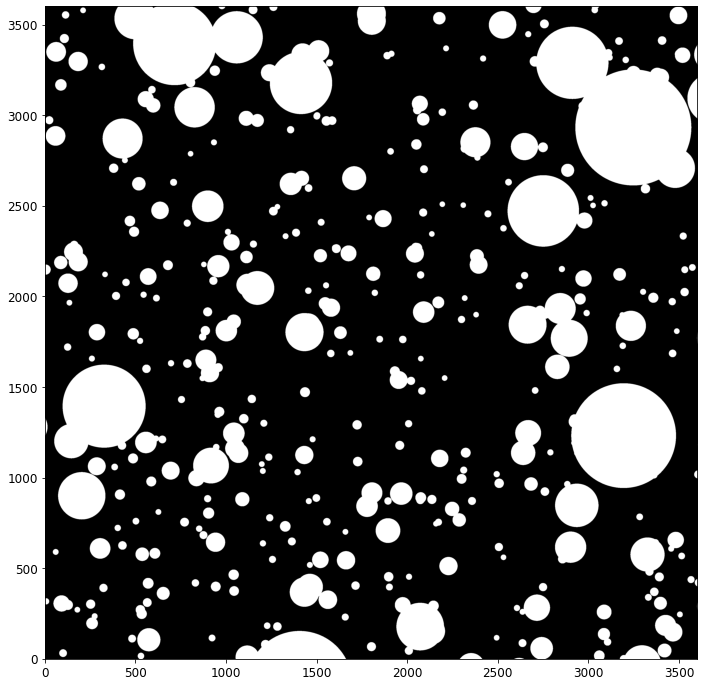

In [11]:
plt.figure(figsize=(12, 12))
plt.imshow(newmask, cmap='gray', origin='lower')
plt.show()

In [12]:
np.mean(pix_ra), np.mean(pix_dec)

(100.21297524688153, 35.11636063631027)

__Compare with DR9 mask__

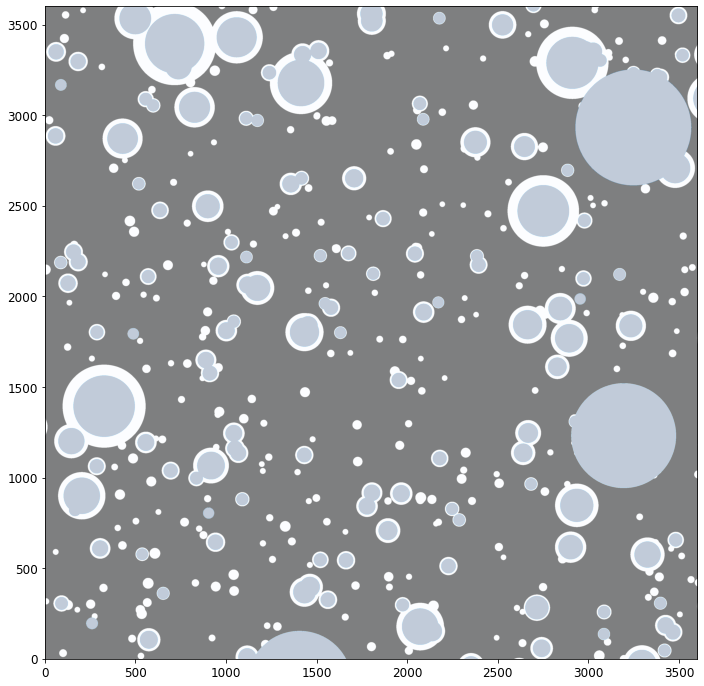

In [13]:
# DR9 MEDIUM mask
m = fitsio.read(img_fn)
img = m & 2**11>0

plt.figure(figsize=(12, 12))
plt.imshow(img, cmap='Blues', origin='lower', alpha=0.5)
# plt.imshow(img, cmap='hot_r', origin='lower', alpha=1., vmax=1.4, vmin=0)
plt.imshow(newmask, cmap='gray', origin='lower', alpha=0.5)
plt.show()

------

In [48]:
output_path = '/global/cfs/cdirs/desi/users/rongpu/tmp/{}-lrgmask.npz'.format(brickname)
np.savez_compressed(output_path, data=newmask.astype(np.int16))

In [49]:
output_path

'/global/cfs/cdirs/desi/users/rongpu/tmp/1003p350-lrgmask.npz'

In [50]:
ls -lh /global/cfs/cdirs/desi/users/rongpu/tmp/1003p350-lrgmask.npz

-rw-rw---- 1 rongpu desi 122K Dec 10 16:05 /global/cfs/cdirs/desi/users/rongpu/tmp/1003p350-lrgmask.npz


In [51]:
fitsio.write?

In [40]:
newmask.astype(np.int16)

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=int16)

In [43]:
output_path.replace('.npz', '.fits')

'/global/cfs/cdirs/desi/users/rongpu/tmp/1003p350-lrgmask.fits'

In [44]:
fitsio.write(output_path.replace('.npz', '.fits'), newmask.astype(np.int16))

In [46]:
ls -lh '/global/cfs/cdirs/desi/users/rongpu/tmp/1003p350-lrgmask.fits'

-rw-rw---- 1 rongpu desi 25M Dec 10 16:02 /global/cfs/cdirs/desi/users/rongpu/tmp/1003p350-lrgmask.fits


In [52]:
fitsio.write(output_path.replace('.npz', '.1.fits'), newmask.astype(np.int16), compress='RICE')

In [53]:
ls -lh '/global/cfs/cdirs/desi/users/rongpu/tmp/1003p350-lrgmask.1.fits'

-rw-rw---- 1 rongpu desi 434K Dec 10 16:06 /global/cfs/cdirs/desi/users/rongpu/tmp/1003p350-lrgmask.1.fits


In [54]:
fitsio.write(output_path.replace('.npz', '.2.fits'), newmask.astype(np.int16), compress='GZIP')

In [55]:
ls -lh '/global/cfs/cdirs/desi/users/rongpu/tmp/1003p350-lrgmask.2.fits'

-rw-rw---- 1 rongpu desi 453K Dec 10 16:06 /global/cfs/cdirs/desi/users/rongpu/tmp/1003p350-lrgmask.2.fits


In [58]:
fitsio.write(output_path.replace('.npz', '.3.fits'), newmask.astype(np.int16), compress='GZIP_2')

In [59]:
ls -lh '/global/cfs/cdirs/desi/users/rongpu/tmp/1003p350-lrgmask.3.fits'

-rw-rw---- 1 rongpu desi 442K Dec 10 16:06 /global/cfs/cdirs/desi/users/rongpu/tmp/1003p350-lrgmask.3.fits


In [60]:
fitsio.write(output_path.replace('.npz', '.4.fits'), newmask.astype(np.int16), compress='HCOMPRESS')

In [61]:
ls -lh '/global/cfs/cdirs/desi/users/rongpu/tmp/1003p350-lrgmask.4.fits'

-rw-rw---- 1 rongpu desi 155K Dec 10 16:07 /global/cfs/cdirs/desi/users/rongpu/tmp/1003p350-lrgmask.4.fits
